# Visualisasi Data Zona Hambat

In [1]:
# Asumsi: Anda sudah punya df = pd.read_csv("path/to/file.csv", ...)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [2]:
file = "hasil disk diffusion.csv"
df = pd.read_csv(file, sep=r'\t', header= 0, engine='python')

print(df)

         Capet cakram  h 24   h 48   h 72  h 96
0   Etanol 96%      1  0,35   1,25   0,65  1,25
1   Etanol 96%      2  0,55   0,55   0,05     0
2   Etanol 96%      3  0,75   0,75      0     0
3   Etanol 96%      +  16,8   22,1  17,85  19,9
4   Etanol 96%      -     0      0      0     0
5   Etanol 70%      1  0,55    0,6    0,1     0
6   Etanol 70%      2   0,6    0,5      0     0
7   Etanol 70%      3   0,3    0,2      0     0
8   Etanol 70%      +  15,2   17,6   15,7  17,8
9   Etanol 70%      -     0      0      0     0
10     Aquades      1     0   0,15      0     0
11     Aquades      2  1,55    0,8      0     0
12     Aquades      3   0,3    0,4      0     0
13     Aquades      +  15,2  18,15   16,8  16,4
14     Aquades      -     0      0      0     0


In [3]:
# Jika CSV memakai koma sebagai desimal tapi dibaca sebagai string, jalankan konversi otomatis:
# (cek satu kolom numeric contoh)
def convert_comma_decimal(col):
    if col.dtype == object:
        # ganti koma ke titik lalu to_numeric
        return pd.to_numeric(col.str.replace(',', '.'), errors='coerce')
    return col

# Terapkan ke semua kolom kecuali Capet dan cakram
for c in df.columns:
    if c not in ['Capet', 'cakram']:
        df[c] = convert_comma_decimal(df[c])

# Jika ingin tetap mempertahankan df asli, filter setelah melt
df_long = df.melt(id_vars=['Capet', 'cakram'],
                  value_vars=['h 24', 'h 48', 'h 72', 'h 96'],
                  var_name='Time', value_name='Value')

# Konversi dan hapus '+' dan '-'
df_long['cakram'] = df_long['cakram'].astype(str)
df_long = df_long[~df_long['cakram'].isin(['+', '-'])].copy()

# Lanjutkan dengan set kategori Time, mapping style, dan plotting

# Pastikan numeric dan urutan waktu
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
time_order = ['h 24', 'h 48', 'h 72', 'h 96']
df_long['Time'] = pd.Categorical(df_long['Time'], categories=time_order, ordered=True)
df_long = df_long.sort_values(['Capet', 'cakram', 'Time'])

# --- mapping style
capet_list = df_long['Capet'].unique()
palette = sns.color_palette("tab10", n_colors=len(capet_list))
color_map = dict(zip(capet_list, palette))

# Tentukan urutan yang diinginkan
desired_order = ['Etanol 96%', 'Etanol 70%', 'Aquades']

# Pastikan nilai cocok persis dengan teks di df_long['Capet']
df_long['Capet'] = pd.Categorical(df_long['Capet'],
                                 categories=desired_order,
                                 ordered=True)

# Ambil capet_list menurut urutan kategori (bukan unique default)
capet_list = list(df_long['Capet'].cat.categories)

# definisikan linestyle untuk cakram umum; sesuaikan jika ada nilai lain
linestyles = {'1': 'solid', '2': 'dashed', '3': 'dotted', '+': 'dashdot', '-': (0, (1, 1))}
df_long['cakram'] = df_long['cakram'].astype(str)

# Buat color map berdasarkan urutan ini
palette_list = sns.color_palette("tab10", n_colors=len(capet_list))
color_map = dict(zip(capet_list, palette_list))

C:\Users\Hype\AppData\Local\Temp\ipykernel_5792\3399421468.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (capet, cakr), grp in df_long.groupby(['Capet', 'cakram']):


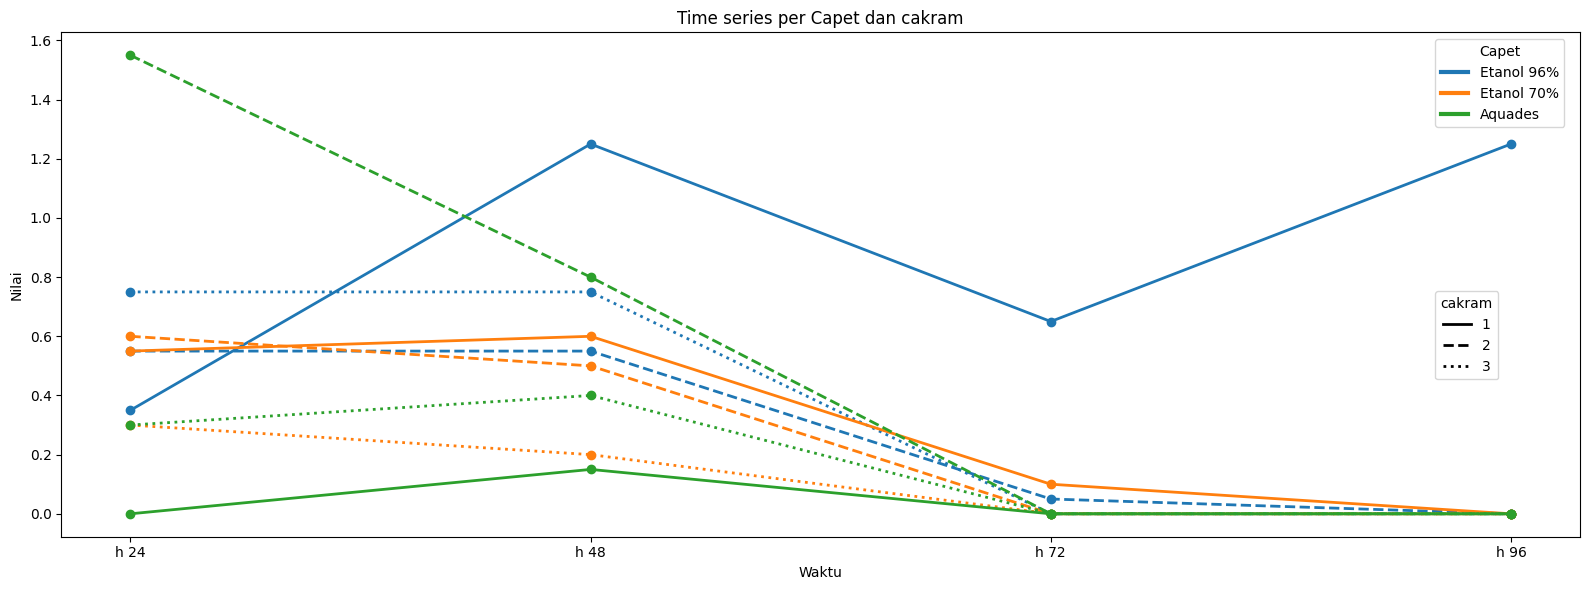

In [4]:
# --- plotting
plt.figure(figsize=(16,6))
ax = plt.gca()

for (capet, cakr), grp in df_long.groupby(['Capet', 'cakram']):
    grp = grp.sort_values('Time')
    ax.plot(range(len(time_order)),            # numeric x: 0..3
            grp['Value'],
            color=color_map[capet],
            linestyle=linestyles.get(cakr, 'solid'),
            marker='o',
            linewidth=2,
            label=f"{capet} | {cakr}")

# x ticks dan labels
ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(time_order)
ax.set_xlabel("Waktu")
ax.set_ylabel("Nilai")
ax.set_title("Time series per Capet dan cakram")

# legend terpisah: warna (Capet) dan pola (cakram)
color_handles = [Line2D([0], [0], color=color_map[c], lw=3) for c in capet_list]
color_labels = list(capet_list)

inok_list_sorted = sorted(df_long['cakram'].unique(), key=str)
style_handles = [Line2D([0], [0], color='black', lw=2, linestyle=linestyles.get(i, 'solid')) for i in inok_list_sorted]
style_labels = inok_list_sorted

leg1 = ax.legend(color_handles, color_labels, title="Capet",
                 loc='upper left', bbox_to_anchor=(0.9, 1))
leg2 = ax.legend(style_handles, style_labels, title="cakram",
                 loc='upper left', bbox_to_anchor=(0.9, 0.5))
ax.add_artist(leg1)
plt.tight_layout()
plt.show()




In [5]:

# Asumsi: df_long sudah tersedia dan kolom nama:
# 'Capet' untuk grup warna, 'cakram' untuk gaya garis (inokulasi sebelumnya)
# pastikan Time dan Value sudah diset: Time categorical ordered, Value numeric
# time_order = ['h 24','h 48','h 72','h 96']

# Buat daftar Capet unik dan mapping warna (dict)
capet_list = list(df_long['Capet'].unique())
palette_list = sns.color_palette("tab10", n_colors=len(capet_list))
color_map = dict(zip(capet_list, palette_list))   # <-- penting: dict, bukan list

# Tentukan urutan yang diinginkan
desired_order = ['Etanol 96%', 'Etanol 70%', 'Aquades']

# Pastikan nilai cocok persis dengan teks di df_long['Capet']
df_long['Capet'] = pd.Categorical(df_long['Capet'],
                                 categories=desired_order,
                                 ordered=True)

# Ambil capet_list menurut urutan kategori (bukan unique default)
capet_list = list(df_long['Capet'].cat.categories)

# Linestyle mapping untuk kolom 'cakram'
linestyles = {'1':'solid','2':'dashed','3':'dotted','+':'dashdot','-':(0,(1,1))}
df_long['cakram'] = df_long['cakram'].astype(str)


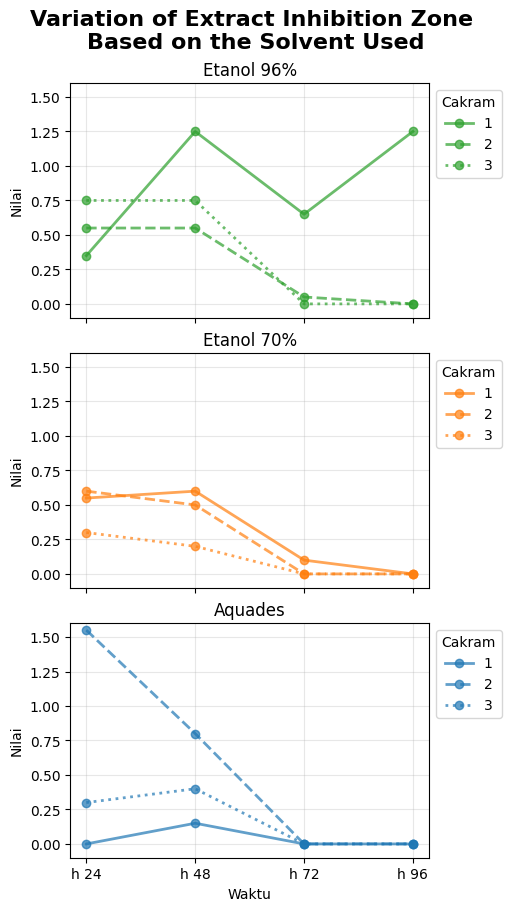

In [6]:

# Subplots: satu baris per Capet
n = len(capet_list)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(5, 3*n),
                         sharex=True, sharey=False, constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, capet in zip(axes, capet_list):
    sub = df_long[df_long['Capet'] == capet]
    for cakr, grp in sub.groupby('cakram'):
        grp = grp.sort_values('Time')
        ax.plot(range(len(time_order)),
                grp['Value'],
                color=color_map[capet],                       # pakai dict mapping
                linestyle=linestyles.get(str(cakr), 'solid'),
                marker='o',
                linewidth=2,
                alpha=0.7, 
                label=f"{cakr}")
    ax.set_title(capet)
    ax.set_xticks(range(len(time_order)))
    ax.set_xticklabels(time_order)
    ax.set_ylabel("Nilai")
    ax.set_ylim(-0.1, 1.6)
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', alpha=0.3)
    ax.legend(title="Cakram", loc='upper left', bbox_to_anchor=(1, 1))

# Tambahkan judul utama
fig.suptitle("Variation of Extract Inhibition Zone \nBased on the Solvent Used", fontsize=16, weight='bold')

axes[-1].set_xlabel("Waktu")
plt.show()
